# 02 - Right Keypress

In [28]:
import sys
# Ruta donde está el módulo 'eogtouch'
module_path = r"C:\Users\Ana\Documents\Ing Salud\TFG\codigo"

# Añadir al path si no está ya
if module_path not in sys.path:
    sys.path.append(module_path)


## Rutinas


In [29]:
import pandas as pd
from os.path import expanduser, join, getmtime, isfile
from glob import glob

import matplotlib.pyplot as plt

from eogtouch.models.enums import StimuliColor
from eogtouch.models.config import GREEN_KEYS, BLUE_KEYS
import pygame



plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250504_175207.parquet")

# Detectar si hay cambio de color del estímulo entre filas consecutivas
df['stimulus_change'] = df['stimuli_color'].diff().abs() > 0

resultados = []

# Solo itero las filas donde hubo un cambio de color del estímulo
for idx, row in df[df['stimulus_change']].iterrows():
    stimulus_time = row['timestamp']
    stimulus_color = row['stimuli_color']

    if stimulus_color not in [StimuliColor.Green.int_value, StimuliColor.Blue.int_value]: 
        continue

    df_window = df[(df['timestamp'] >= stimulus_time) & (df['timestamp'] <= stimulus_time + 5000)] # creo una ventana de 5 segundos para comprobar la tecla pulsada

    key_row = df_window[df_window["key"] > 0].head(1)
    if not key_row.empty:
        key_pressed = int(key_row["key"].values[0])
        is_correct = False

        if stimulus_color == StimuliColor.Green.int_value:
            is_correct = key_pressed in GREEN_KEYS
        elif stimulus_color == StimuliColor.Blue.int_value:
            is_correct = key_pressed in BLUE_KEYS

        color_enum = StimuliColor.from_int_value(stimulus_color)
        key_name = pygame.key.name(key_pressed)
        result = "bien" if is_correct else "fallo"
        
        
        print(f"StimuliColor: {color_enum.name}  Tecla: {key_name} = {result}")
        response_time = key_row["timestamp"].values[0] - stimulus_time

        resultados.append({
            "stimulus_index": idx,
            "color": color_enum.name,
            "key": key_name,
            "correct": is_correct,
            "response_time_ms": response_time
        })

    else:
        print(f"No se presionó ninguna tecla. Fila: {idx}")
        color_enum = StimuliColor.from_int_value(stimulus_color)
        resultados.append({
            "stimulus_index": idx,
            "color": color_enum.name,
            "key": None,
            "correct": False,
            "response_time_ms": None
        })
        
    df_resultados = pd.DataFrame(resultados)




StimuliColor: Green  Tecla: k = fallo
StimuliColor: Green  Tecla: s = bien
StimuliColor: Green  Tecla: s = bien
StimuliColor: Blue  Tecla: a = fallo
StimuliColor: Blue  Tecla: l = bien
StimuliColor: Green  Tecla: s = bien
StimuliColor: Green  Tecla: w = bien
StimuliColor: Green  Tecla: e = bien
StimuliColor: Green  Tecla: x = bien
StimuliColor: Blue  Tecla: l = bien
StimuliColor: Green  Tecla: w = bien
StimuliColor: Green  Tecla: l = fallo
StimuliColor: Green  Tecla: m = fallo
StimuliColor: Green  Tecla: x = bien
StimuliColor: Green  Tecla: q = bien
StimuliColor: Blue  Tecla:  = fallo
StimuliColor: Blue  Tecla:  = fallo


## Tiempo de respuesta para cada color

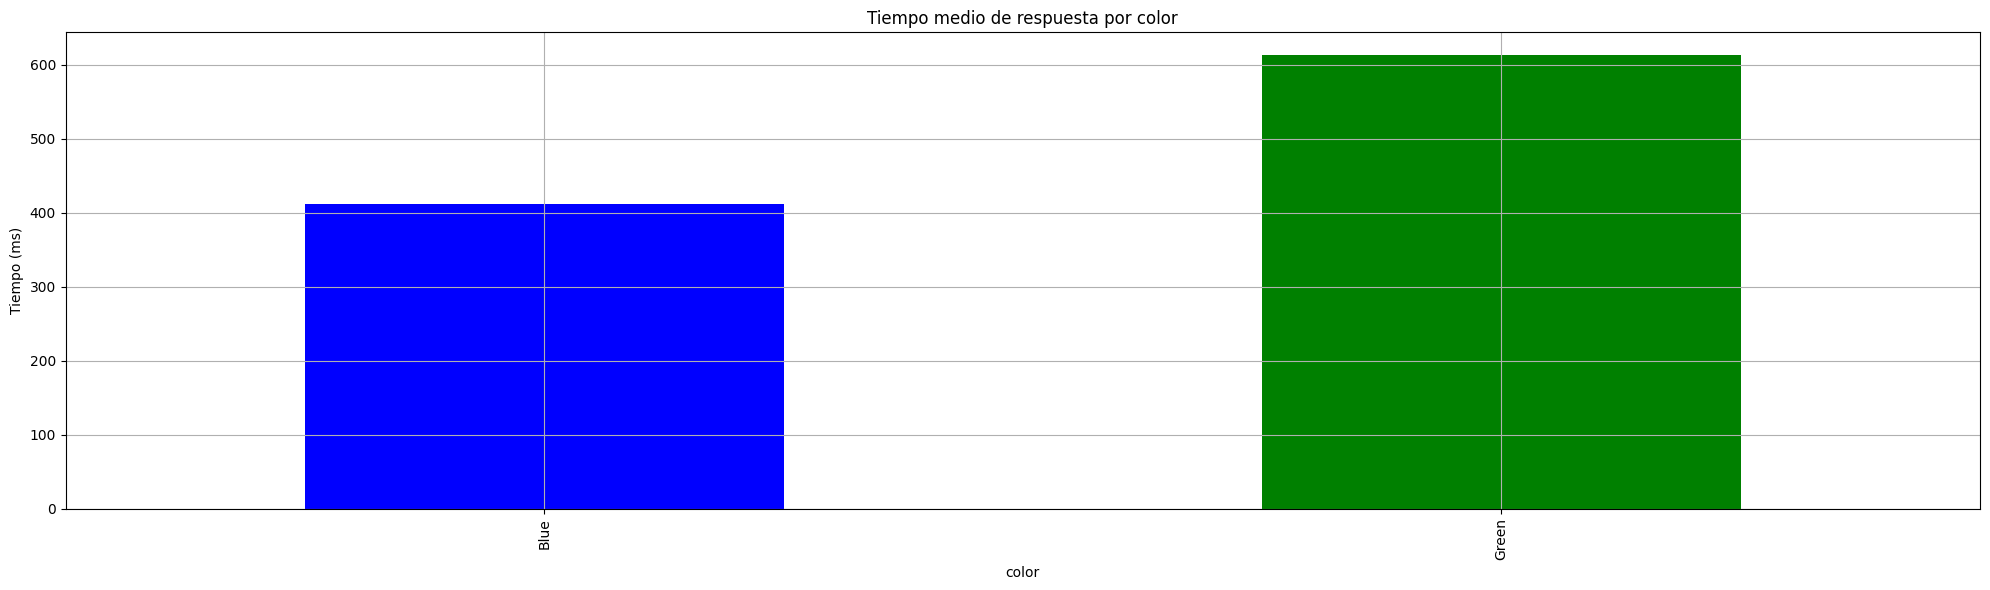

In [30]:
# Filtrar solo las respuestas que tienen tiempo registrado
tiempos = df_resultados[df_resultados["response_time_ms"].notnull()]

# Calcular tiempo medio de respuesta por color
tiempo_medio = tiempos.groupby("color")["response_time_ms"].mean()

# Crear el gráfico de barras con colores personalizados
color_map = {"Green": "green", "Blue": "blue"}
bar_colors = [color_map[color] for color in tiempo_medio.index]

# Graficar
tiempo_medio.plot(kind="bar", title="Tiempo medio de respuesta por color", color=bar_colors)
plt.ylabel("Tiempo (ms)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Precision

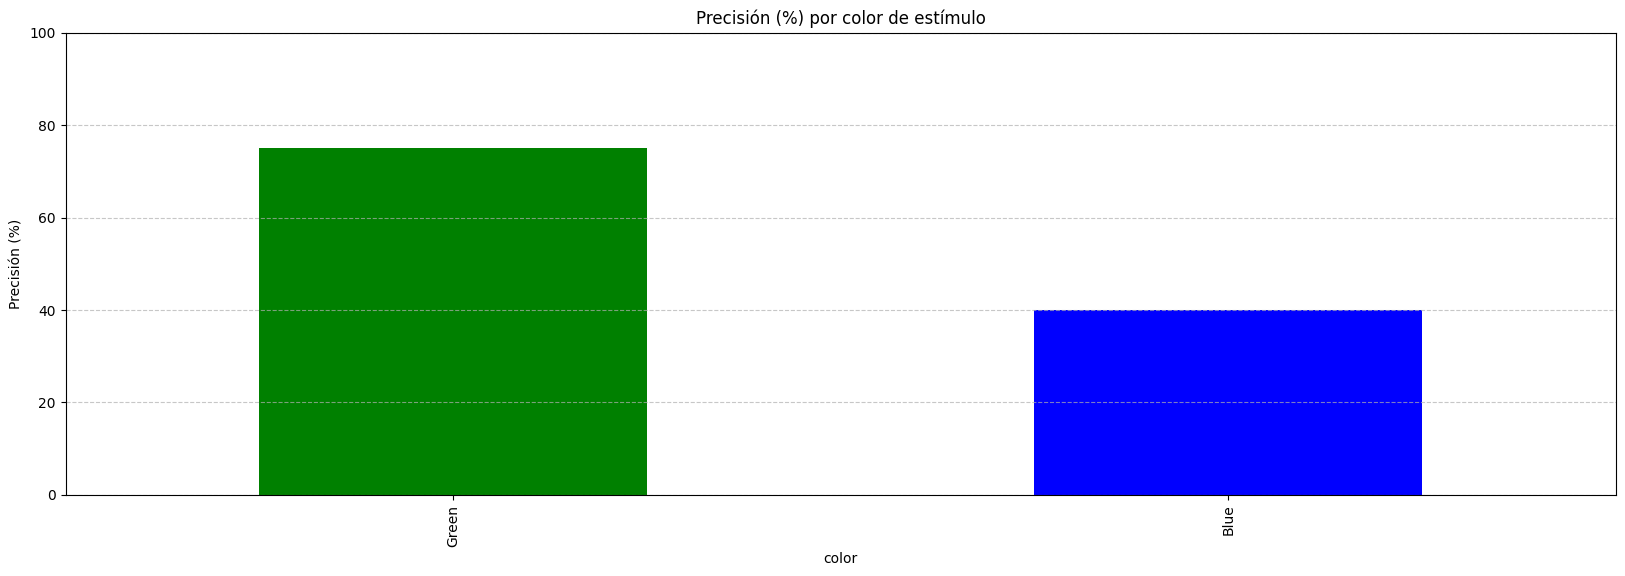

In [31]:
import matplotlib.pyplot as plt

# Asegurar orden correcto
precision_color = df_resultados.groupby("color")["correct"].mean() * 100
precision_color = precision_color.reindex(['Green', 'Blue'])

color_map = {'Green': 'green', 'Blue': 'blue'}
colors = [color_map[c] for c in precision_color.index]

precision_color.plot(kind='bar', color=colors)
plt.title("Precisión (%) por color de estímulo")
plt.ylabel("Precisión (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Número de errores

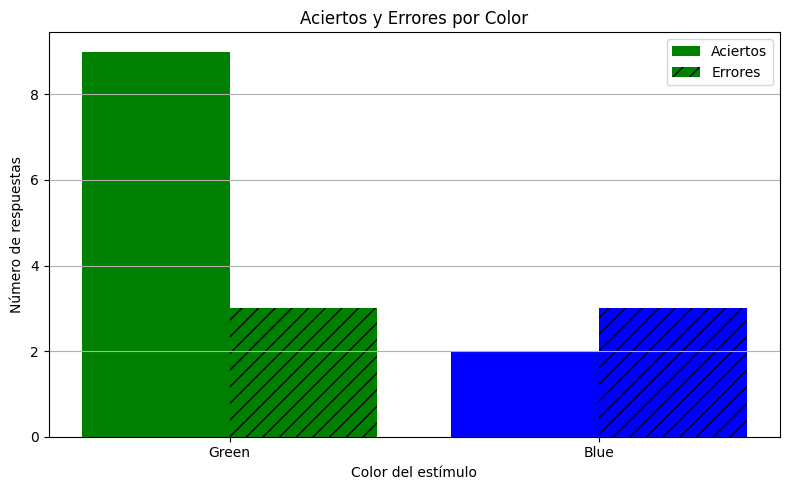

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar aciertos y errores
errores = df_resultados[df_resultados["correct"] == False]
aciertos = df_resultados[df_resultados["correct"] == True]

# Contar por color
errores_por_color = errores["color"].value_counts().reindex(["Green", "Blue"], fill_value=0)
aciertos_por_color = aciertos["color"].value_counts().reindex(["Green", "Blue"], fill_value=0)

# Crear gráfico combinado
colors = ["green", "blue"]
labels = ["Green", "Blue"]
x = range(len(labels))

plt.figure(figsize=(8, 5))

# Aciertos (barra a la izquierda de cada color)
plt.bar([i - 0.2 for i in x], aciertos_por_color, width=0.4, label="Aciertos", color=colors)

# Errores (barra a la derecha de cada color)
plt.bar([i + 0.2 for i in x], errores_por_color, width=0.4, label="Errores", color=colors, hatch='//')

# Personalizar ejes y leyenda
plt.xticks(x, labels)
plt.xlabel("Color del estímulo")
plt.ylabel("Número de respuestas")
plt.title("Aciertos y Errores por Color")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()



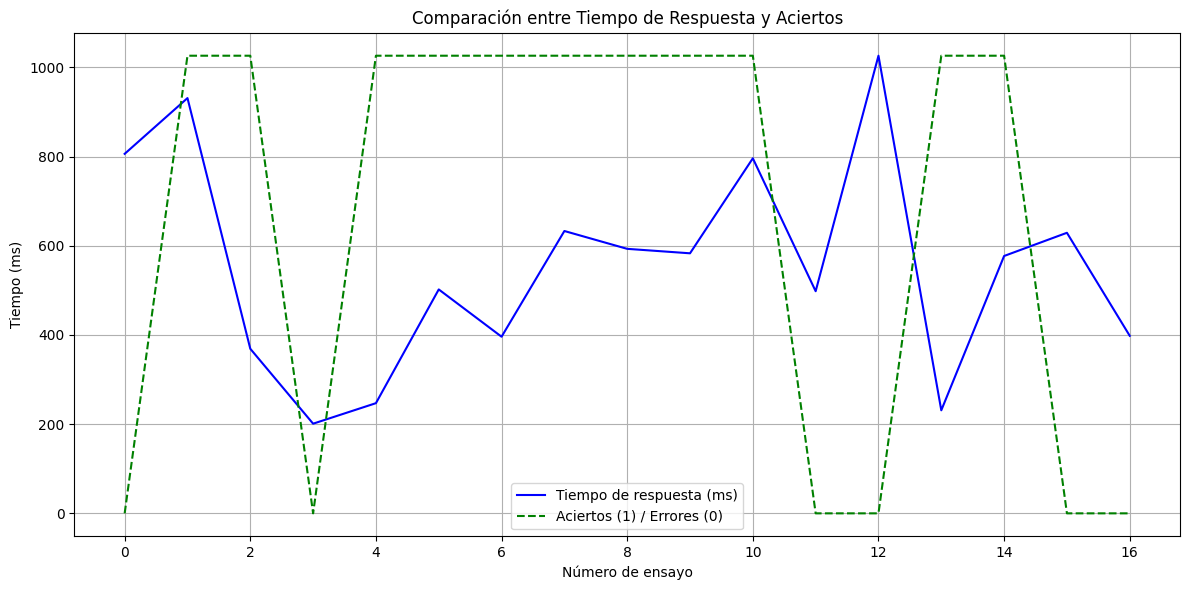

Correlación: -0.125
Valor p: 0.6338
Color: Green
  Correlación: -0.414
  Valor p: 0.1804
Color: Blue
  Correlación: 0.016
  Valor p: 0.9795


In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de que tus datos están ordenados por tiempo o por índice
df_resultados = df_resultados.sort_index()

# Convertir 'correct' a enteros: 1 = acierto, 0 = error
df_resultados["correct_int"] = df_resultados["correct"].astype(int)

# Filtrar valores con tiempos válidos
df_filtrado = df_resultados[df_resultados["response_time_ms"].notnull()]

# Crear gráfico de líneas
plt.figure(figsize=(12, 6))

# Línea 1: Tiempo de respuesta
plt.plot(df_filtrado.index, df_filtrado["response_time_ms"], label="Tiempo de respuesta (ms)", color="blue")

# Línea 2: Aciertos / errores
plt.plot(df_filtrado.index, df_filtrado["correct_int"] * df_filtrado["response_time_ms"].max(), 
         label="Aciertos (1) / Errores (0)", color="green", linestyle="--")

# Agregar etiquetas
plt.title("Comparación entre Tiempo de Respuesta y Aciertos")
plt.xlabel("Número de ensayo")
plt.ylabel("Tiempo (ms)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


from scipy.stats import pearsonr

# Asegúrate de trabajar con datos válidos
df_validos = df_resultados[df_resultados["response_time_ms"].notnull()]
df_validos["correct_int"] = df_validos["correct"].astype(int)

# Correlación entre tiempo y acierto
corr, p_value = pearsonr(df_validos["response_time_ms"], df_validos["correct_int"])

print(f"Correlación: {corr:.3f}")
print(f"Valor p: {p_value:.4f}")


for color in ["Green", "Blue"]:
    df_color = df_validos[df_validos["color"] == color]
    corr, p_value = pearsonr(df_color["response_time_ms"], df_color["correct_int"])
    print(f"Color: {color}")
    print(f"  Correlación: {corr:.3f}")
    print(f"  Valor p: {p_value:.4f}")

